# SAIR Dataset Clustering (Stage 1)
## Fast clustering for LigandMPNN benchmarking

**Clustering criteria:**
1. Affinity tiers (tight binders vs non-binders)
2. Protein family (from 'family' column)
3. Protein size bins
4. Ligand properties (from SMILES)

**Output:** ~500-1000 clustered representatives for Stage 2 validation

## 1. Setup

### 1-1. Imports

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
import json
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("✅ Imports complete")

✅ Imports complete


### 1-2. Configuration

In [95]:
# Input/Output paths
INPUT_CSV = "/scratch/yunmin/data/db/graph/sair/filtered/sair_pIC50_all_tight_val.csv"
OUT_DIR = Path("/scratch/yunmin/data/db/graph/sair/clustered")
OUT_PLOTS_DIR = OUT_DIR / "plots"
OUT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Clustering parameters
TARGET_SAMPLES = 250
TIGHT_BINDER_CUTOFF = 8.5  # pIC50 >= 8.5 for tight binders
NON_BINDER_CUTOFF = 4.5     # pIC50 <= 4.5 for non-binders
MIN_TARGETS_PER_PROTEIN = 8
MIN_OFFTARGETS_PER_PROTEIN = 8

print(f"Configuration:")
print(f"  Input: {INPUT_CSV}")
print(f"  Output: {OUT_DIR}")
print(f"  Target samples: {TARGET_SAMPLES}")
print(f"  Tight binder cutoff: pIC50 >= {TIGHT_BINDER_CUTOFF}")
print(f"  Non-binder cutoff: pIC50 <= {NON_BINDER_CUTOFF}")

Configuration:
  Input: /scratch/yunmin/data/db/graph/sair/filtered/sair_pIC50_all_tight_val.csv
  Output: /scratch/yunmin/data/db/graph/sair/clustered
  Target samples: 250
  Tight binder cutoff: pIC50 >= 8.5
  Non-binder cutoff: pIC50 <= 4.5


## 2. Load Data

### 2-1. Load data

In [96]:
print(f"Loading data from {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)
initial_rows = len(df)

print(f"\n✅ Loaded {initial_rows:,} rows")
print(f"  - Unique proteins: {df['protein'].nunique():,}")
print(f"  - Targets: {(df['target_type'] == 'target').sum():,}")
print(f"  - Off-targets: {(df['target_type'] == 'off_target').sum():,}")

# Show first few rows
df.head()

Loading data from /scratch/yunmin/data/db/graph/sair/filtered/sair_pIC50_all_tight_val.csv...

✅ Loaded 75,409 rows
  - Unique proteins: 497
  - Targets: 54,755
  - Off-targets: 20,654


,entry_id,index,protein,sequence,sequence_length,ligand_smiles,pIC50,target_type,source,assay,family,description,vina_score_min,number_clashes,internal_energy,confidence_score,complex_plddt,complex_iplddt,ptm,iptm
0,654,0,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,C[C@H]1OC(=O)N(c2nc(-c3cnc(N)nc3C(F)(F)F)cc(N3...,5.338621,off_target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-10.7393,1.0,1.0,0.930772,0.916796,0.899851,0.967878,0.986674
1,674,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,Nc1cc(C(F)(F)F)c(-c2cc(NC(CO)Cc3ccccc3)nc(N3CC...,5.209330,off_target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-8.8858,1.0,1.0,0.921381,0.912904,0.847111,0.957527,0.955291
2,662,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,Cn1c(=O)n(-c2ccc(C(C)(C)C#N)cc2)c2c3cc(-c4cnc5...,8.277862,target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-11.6466,1.0,1.0,0.928460,0.914086,0.895977,0.964621,0.985958
3,634,4,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,CC1C(c2cccnc2)OC(=O)N1c1cc(-c2cnc(N)nc2C(F)(F)...,7.537602,target,BindingDB,na,kinase,US10202371,-10.7742,1.0,1.0,0.921728,0.910370,0.871247,0.957377,0.967160
4,660,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,C[C@H]1[C@H](c2nccs2)OC(=O)N1c1cc(-c2cnc(N)nc2...,7.508638,target,BindingDB,na,kinase,US10202371,-10.3188,1.0,1.0,0.925128,0.912977,0.879408,0.965920,0.973730


### 2-2. Initial Data Exploration

In [97]:
# Check available columns
print("Available columns:")
print(df.columns.tolist())

Available columns:
['entry_id', 'index', 'protein', 'sequence', 'sequence_length', 'ligand_smiles', 'pIC50', 'target_type', 'source', 'assay', 'family', 'description', 'vina_score_min', 'number_clashes', 'internal_energy', 'confidence_score', 'complex_plddt', 'complex_iplddt', 'ptm', 'iptm']


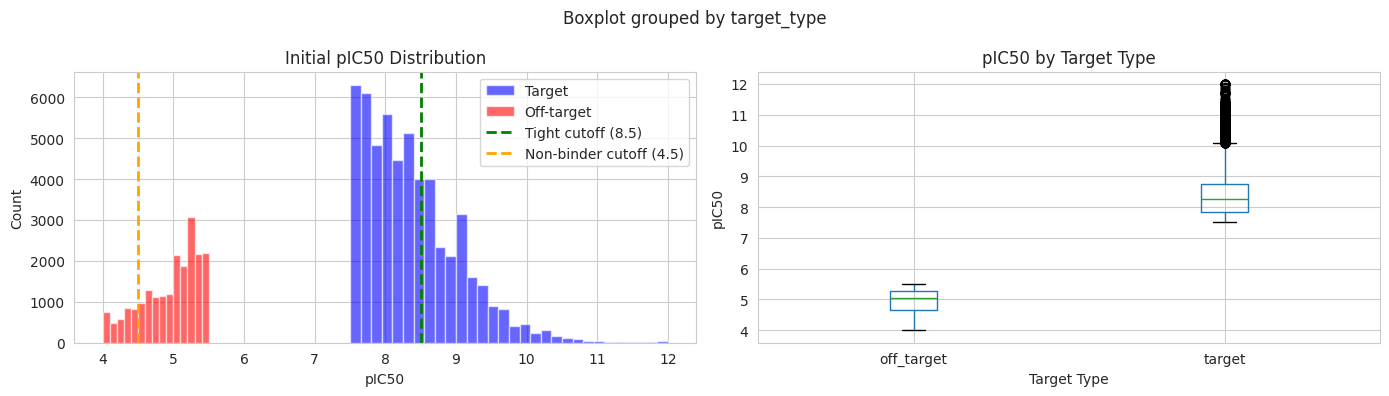

In [98]:
# pIC50 distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall distribution
axes[0].hist(df[df['target_type'] == 'target']['pIC50'], bins=30, alpha=0.6, label='Target', color='blue')
axes[0].hist(df[df['target_type'] == 'off_target']['pIC50'], bins=15, alpha=0.6, label='Off-target', color='red')
axes[0].axvline(TIGHT_BINDER_CUTOFF, color='green', linestyle='--', linewidth=2, label=f'Tight cutoff ({TIGHT_BINDER_CUTOFF})')
axes[0].axvline(NON_BINDER_CUTOFF, color='orange', linestyle='--', linewidth=2, label=f'Non-binder cutoff ({NON_BINDER_CUTOFF})')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('Initial pIC50 Distribution')
axes[0].legend()

# Box plot by target type
df.boxplot(column='pIC50', by='target_type', ax=axes[1])
axes[1].set_title('pIC50 by Target Type')
axes[1].set_xlabel('Target Type')
axes[1].set_ylabel('pIC50')

plt.tight_layout()
plt.show()

## 5. Protein Filtering (≥n targets AND ≥n off-targets)

In [99]:
print("="*60)
print("PROTEIN FILTERING: Ensuring sufficient targets/off-targets")
print("="*60)

print(f"\nRequiring each protein to have:")
print(f"  - At least {MIN_TARGETS_PER_PROTEIN} target entries")
print(f"  - At least {MIN_OFFTARGETS_PER_PROTEIN} off-target entries")

# Count targets and off-targets per protein
protein_counts = df.groupby('protein')['target_type'].value_counts().unstack(fill_value=0)

# Ensure columns exist
if 'target' not in protein_counts.columns:
    protein_counts['target'] = 0
if 'off_target' not in protein_counts.columns:
    protein_counts['off_target'] = 0

print(f"\nBefore filtering:")
print(f"  - Total proteins: {len(protein_counts):,}")
print(f"  - Proteins with ≥{MIN_TARGETS_PER_PROTEIN} targets: {(protein_counts['target'] >= MIN_TARGETS_PER_PROTEIN).sum():,}")
print(f"  - Proteins with ≥{MIN_OFFTARGETS_PER_PROTEIN} off-targets: {(protein_counts['off_target'] >= MIN_OFFTARGETS_PER_PROTEIN).sum():,}")

# Filter proteins
valid_proteins = protein_counts[
    (protein_counts['target'] >= MIN_TARGETS_PER_PROTEIN) &
    (protein_counts['off_target'] >= MIN_OFFTARGETS_PER_PROTEIN)
].index

print(f"\n✅ After filtering:")
print(f"  - Valid proteins: {len(valid_proteins):,}")

# Filter dataframe
df_filtered = df[df['protein'].isin(valid_proteins)].copy()
print(f"  - Rows retained: {len(df_filtered):,} / {len(df):,} ({len(df_filtered)/len(df)*100:.1f}%)")

PROTEIN FILTERING: Ensuring sufficient targets/off-targets

Requiring each protein to have:
  - At least 8 target entries
  - At least 8 off-target entries

Before filtering:
  - Total proteins: 497
  - Proteins with ≥8 targets: 297
  - Proteins with ≥8 off-targets: 307

✅ After filtering:
  - Valid proteins: 220
  - Rows retained: 67,102 / 75,409 (89.0%)



PER-PROTEIN TARGET/OFF-TARGET ANALYSIS


/tmp/ipykernel_481727/484956316.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(box_data, labels=['Targets', 'Off-targets'],


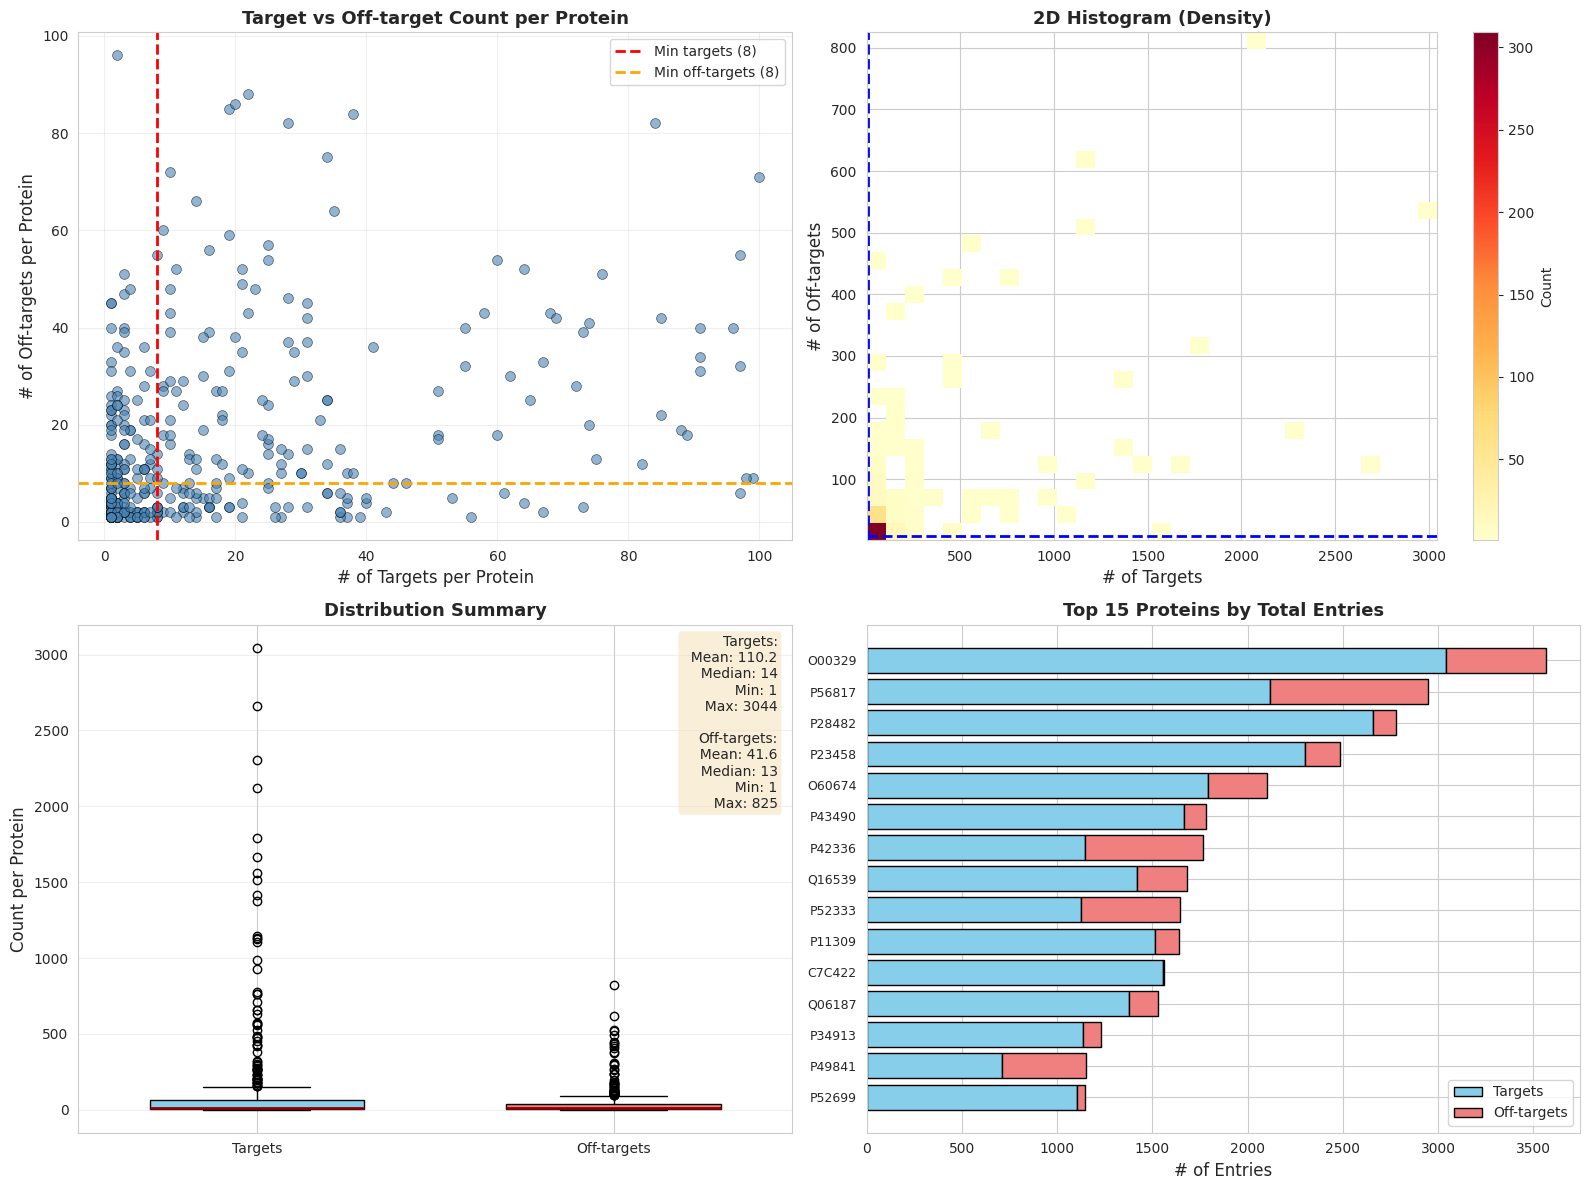

✅ Saved protein analysis plot to /scratch/yunmin/data/db/graph/sair/clustered/plots/protein_target_offtarget_analysis.png

Detailed Statistics:
# of proteins: 497

Targets per protein:
  Mean ± Std: 110.2 ± 320.2
  Median (IQR): 14 (3-64)
  Range: 1-3044

Off-targets per protein:
  Mean ± Std: 41.6 ± 86.6
  Median (IQR): 13 (4-39)
  Range: 1-825

Total entries per protein:
  Mean ± Std: 151.7 ± 376.2
  Range: 2-3567

Proteins with most targets (top 5):
target_type  target  off_target  total
protein                               
O00329         3044         523   3567
P28482         2659         121   2780
P23458         2304         180   2484
P56817         2120         825   2945
O60674         1791         310   2101

Proteins with most off-targets (top 5):
target_type  target  off_target  total
protein                               
P56817         2120         825   2945
P42336         1147         619   1766
O00329         3044         523   3567
P52333         1125         520   

In [100]:
# Detailed per-protein target/off-target analysis
print("\n" + "="*60)
print("PER-PROTEIN TARGET/OFF-TARGET ANALYSIS")
print("="*60)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot: Targets vs Off-targets per protein
axes[0, 0].scatter(protein_counts[(protein_counts['target']<=100) & (protein_counts['off_target']<=100)]['target'], 
                   protein_counts[(protein_counts['target']<=100) & (protein_counts['off_target']<=100)]['off_target'], 
                   alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0, 0].axvline(MIN_TARGETS_PER_PROTEIN, color='red', linestyle='--', linewidth=2, label=f'Min targets ({MIN_TARGETS_PER_PROTEIN})')
axes[0, 0].axhline(MIN_OFFTARGETS_PER_PROTEIN, color='orange', linestyle='--', linewidth=2, label=f'Min off-targets ({MIN_OFFTARGETS_PER_PROTEIN})')
axes[0, 0].set_xlabel('# of Targets per Protein', fontsize=12)
axes[0, 0].set_ylabel('# of Off-targets per Protein', fontsize=12)
axes[0, 0].set_title('Target vs Off-target Count per Protein', fontweight='bold', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Joint distribution histogram
axes[0, 1].hist2d(protein_counts['target'], protein_counts['off_target'], 
                  bins=30, cmap='YlOrRd', cmin=1)
axes[0, 1].axvline(MIN_TARGETS_PER_PROTEIN, color='blue', linestyle='--', linewidth=2)
axes[0, 1].axhline(MIN_OFFTARGETS_PER_PROTEIN, color='blue', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('# of Targets', fontsize=12)
axes[0, 1].set_ylabel('# of Off-targets', fontsize=12)
axes[0, 1].set_title('2D Histogram (Density)', fontweight='bold', fontsize=13)
plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Count')

# 3. Box plot comparison
box_data = [protein_counts['target'], protein_counts['off_target']]
bp = axes[1, 0].boxplot(box_data, labels=['Targets', 'Off-targets'], 
                        patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('lightcoral')
for median in bp['medians']:
    median.set(color='darkred', linewidth=2)
axes[1, 0].set_ylabel('Count per Protein', fontsize=12)
axes[1, 0].set_title('Distribution Summary', fontweight='bold', fontsize=13)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add statistics text
stats_text = f"Targets:\n"
stats_text += f"  Mean: {protein_counts['target'].mean():.1f}\n"
stats_text += f"  Median: {protein_counts['target'].median():.0f}\n"
stats_text += f"  Min: {protein_counts['target'].min()}\n"
stats_text += f"  Max: {protein_counts['target'].max()}\n\n"
stats_text += f"Off-targets:\n"
stats_text += f"  Mean: {protein_counts['off_target'].mean():.1f}\n"
stats_text += f"  Median: {protein_counts['off_target'].median():.0f}\n"
stats_text += f"  Min: {protein_counts['off_target'].min()}\n"
stats_text += f"  Max: {protein_counts['off_target'].max()}"

axes[1, 0].text(0.98, 0.98, stats_text, transform=axes[1, 0].transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Top proteins by total entries
protein_counts['total'] = protein_counts['target'] + protein_counts['off_target']
top_proteins = protein_counts.nlargest(15, 'total')

y_pos = np.arange(len(top_proteins))
axes[1, 1].barh(y_pos, top_proteins['target'], label='Targets', color='skyblue', edgecolor='black')
axes[1, 1].barh(y_pos, top_proteins['off_target'], left=top_proteins['target'], 
                label='Off-targets', color='lightcoral', edgecolor='black')
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in top_proteins.index], fontsize=9)
axes[1, 1].set_xlabel('# of Entries', fontsize=12)
axes[1, 1].set_title('Top 15 Proteins by Total Entries', fontweight='bold', fontsize=13)
axes[1, 1].legend()
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'protein_target_offtarget_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved protein analysis plot to {OUT_DIR / 'plots' / 'protein_target_offtarget_analysis.png'}")

# Print detailed statistics
print(f"\nDetailed Statistics:")
print(f"{'='*60}")
print(f"# of proteins: {len(protein_counts)}")
print(f"\nTargets per protein:")
print(f"  Mean ± Std: {protein_counts['target'].mean():.1f} ± {protein_counts['target'].std():.1f}")
print(f"  Median (IQR): {protein_counts['target'].median():.0f} ({protein_counts['target'].quantile(0.25):.0f}-{protein_counts['target'].quantile(0.75):.0f})")
print(f"  Range: {protein_counts['target'].min()}-{protein_counts['target'].max()}")

print(f"\nOff-targets per protein:")
print(f"  Mean ± Std: {protein_counts['off_target'].mean():.1f} ± {protein_counts['off_target'].std():.1f}")
print(f"  Median (IQR): {protein_counts['off_target'].median():.0f} ({protein_counts['off_target'].quantile(0.25):.0f}-{protein_counts['off_target'].quantile(0.75):.0f})")
print(f"  Range: {protein_counts['off_target'].min()}-{protein_counts['off_target'].max()}")

print(f"\nTotal entries per protein:")
print(f"  Mean ± Std: {protein_counts['total'].mean():.1f} ± {protein_counts['total'].std():.1f}")
print(f"  Range: {protein_counts['total'].min()}-{protein_counts['total'].max()}")

# Show proteins with extreme counts
print(f"\n{'='*60}")
print("Proteins with most targets (top 5):")
print(protein_counts.nlargest(5, 'target')[['target', 'off_target', 'total']])

print(f"\nProteins with most off-targets (top 5):")
print(protein_counts.nlargest(5, 'off_target')[['target', 'off_target', 'total']])

print(f"\nProteins with most total entries (top 5):")
print(protein_counts.nlargest(5, 'total')[['target', 'off_target', 'total']])

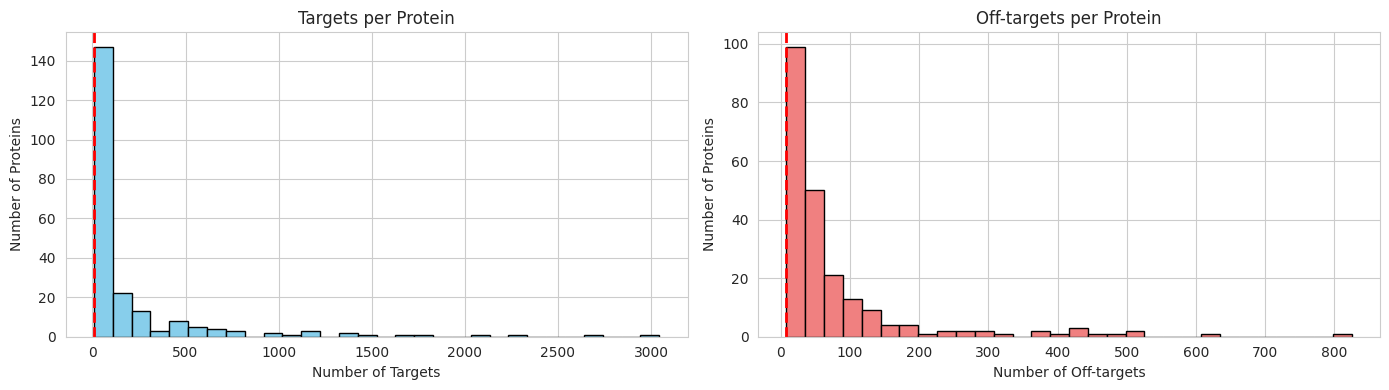


Statistics:
  Target entries - Mean: 224.6, Median: 61
  Off-target entries - Mean: 80.4, Median: 40


In [101]:
# Show distribution after filtering
protein_counts = df_filtered.groupby('protein')['target_type'].value_counts().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Targets per protein
axes[0].hist(protein_counts['target'], bins=30, color='skyblue', edgecolor='black')
axes[0].axvline(MIN_TARGETS_PER_PROTEIN, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Number of Targets')
axes[0].set_ylabel('Number of Proteins')
axes[0].set_title('Targets per Protein')

# Off-targets per protein
axes[1].hist(protein_counts['off_target'], bins=30, color='lightcoral', edgecolor='black')
axes[1].axvline(MIN_OFFTARGETS_PER_PROTEIN, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Number of Off-targets')
axes[1].set_ylabel('Number of Proteins')
axes[1].set_title('Off-targets per Protein')

plt.tight_layout()
plt.show()

print(f"\nStatistics:")
print(f"  Target entries - Mean: {protein_counts['target'].mean():.1f}, Median: {protein_counts['target'].median():.0f}")
print(f"  Off-target entries - Mean: {protein_counts['off_target'].mean():.1f}, Median: {protein_counts['off_target'].median():.0f}")

## 6. Feature Engineering

### 6.1 Affinity Tiers

Affinity tier distribution:
affinity_tier
moderate_binder (<8.5)    31224
tight_binder (>=8.5)      18184
weak_binder (>4.5)        14777
non_binder (≤4.5)          2917
Name: count, dtype: int64


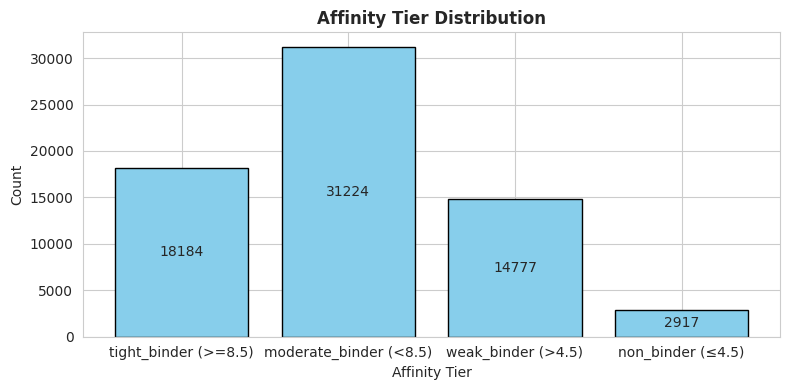

In [102]:
def classify_affinity_tier(row):
    """Classify into affinity tiers with focus on extreme binders."""
    pic50 = row['pIC50']
    target_type = row['target_type']
    
    if target_type == 'target':
        if pic50 >= TIGHT_BINDER_CUTOFF:
            return f'tight_binder (>={TIGHT_BINDER_CUTOFF})'
        else:
            return f'moderate_binder (<{TIGHT_BINDER_CUTOFF})'
    else:  # off_target
        if pic50 <= NON_BINDER_CUTOFF:
            return f'non_binder (≤{NON_BINDER_CUTOFF})'
        else:
            return f'weak_binder (>{NON_BINDER_CUTOFF})'

df_filtered['affinity_tier'] = df_filtered.apply(classify_affinity_tier, axis=1)
print("Affinity tier distribution:")
print(df_filtered['affinity_tier'].value_counts())

# Visualize Bar graph
order=[
    f'tight_binder (>={TIGHT_BINDER_CUTOFF})',
    f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
    f'weak_binder (>{NON_BINDER_CUTOFF})',
    f'non_binder (≤{NON_BINDER_CUTOFF})',
    ]
df_filtered['affinity_tier'] = pd.Categorical(df_filtered['affinity_tier'], categories=order, ordered=True)
counts = df_filtered['affinity_tier'].value_counts(sort=False)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax.set_title('Affinity Tier Distribution', fontweight='bold')
ax.set_xlabel('Affinity Tier')
ax.set_ylabel('Count')
ax.bar_label(bars, labels=[f'{v}' for v in counts.values], label_type='center', padding=0)

plt.tight_layout()
plt.show()

### 6.2 Protein Family (from 'family' column)

✅ Using 'family' column

Protein family distribution:
protein_family
kinase              31412
enzyme              27080
phosphatase          4261
other                3138
GPCR                 1052
nuclear receptor      159
Name: count, dtype: int64


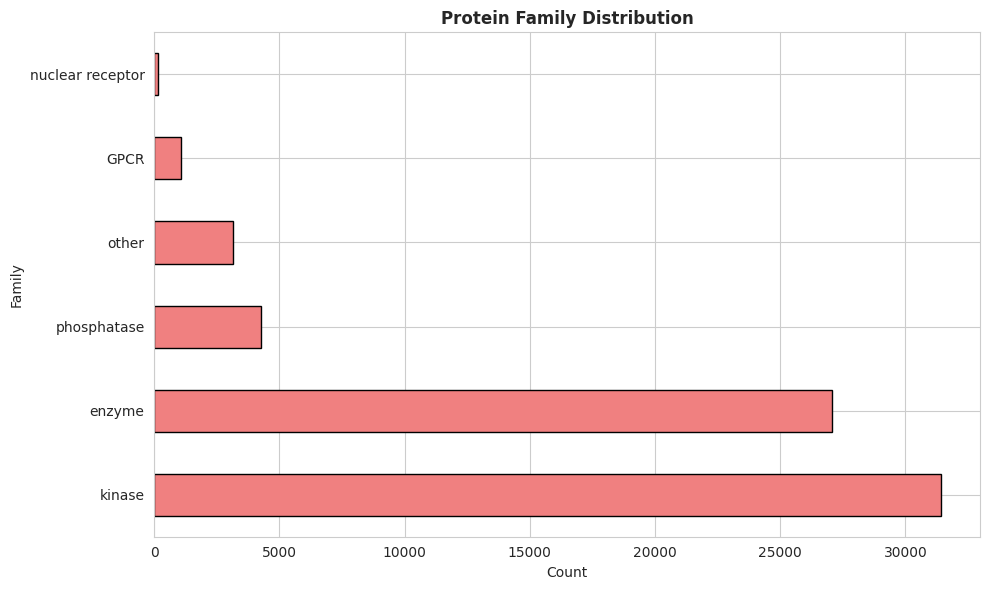

In [103]:
# Use 'family' column if available, otherwise classify by name
if 'family' in df_filtered.columns:
    df_filtered['protein_family'] = df_filtered['family'].fillna('unknown')
    print("✅ Using 'family' column")
else:
    print("⚠️  'family' column not found, using name-based classification")
    # Fallback to name-based classification if needed
    df_filtered['protein_family'] = 'other'

print("\nProtein family distribution:")
family_counts = df_filtered['protein_family'].value_counts()
print(family_counts)

# Visualize top 15
family_counts.plot(kind='barh', color='lightcoral', edgecolor='black', figsize=(10, 6))
plt.title('Protein Family Distribution', fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Family')
plt.tight_layout()
plt.show()

### 6.3 Protein Size Categories

Size distribution:
size_category
very_large    32095
large         25438
medium         9001
small           568
Name: count, dtype: int64


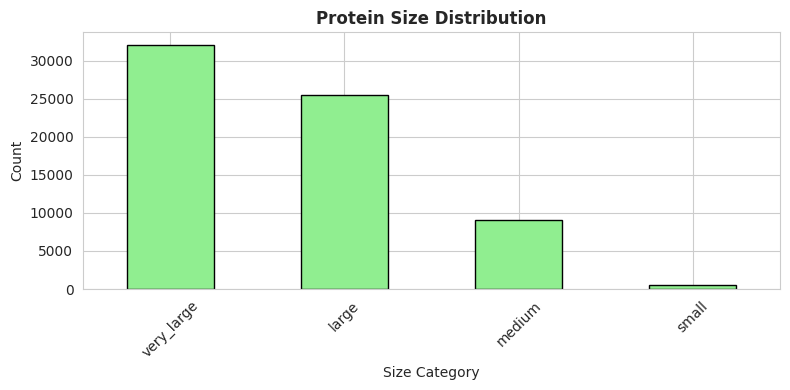

In [104]:
def categorize_protein_size(seq_length):
    """Categorize protein by sequence length."""
    if seq_length < 150:
        return 'small'
    elif seq_length < 300:
        return 'medium'
    elif seq_length < 500:
        return 'large'
    else:
        return 'very_large'

df_filtered['size_category'] = df_filtered['sequence_length'].apply(categorize_protein_size)

print("Size distribution:")
print(df_filtered['size_category'].value_counts())

# Visualize
df_filtered['size_category'].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black', figsize=(8, 4))
plt.title('Protein Size Distribution', fontweight='bold')
plt.xlabel('Size Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.4 Ligand Properties (from SMILES)

In [105]:
def calculate_ligand_features(smiles):
    """Calculate ligand properties from SMILES."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        return {
            'mw': Descriptors.MolWt(mol),
            'logp': Descriptors.MolLogP(mol),
            'hbd': Lipinski.NumHDonors(mol),
            'hba': Lipinski.NumHAcceptors(mol),
            'rotatable_bonds': Lipinski.NumRotatableBonds(mol),
            'aromatic_rings': Lipinski.NumAromaticRings(mol),
            'heavy_atoms': Lipinski.HeavyAtomCount(mol)
        }
    except:
        return None

def categorize_ligand_size(mw):
    """Categorize ligand by molecular weight."""
    if mw < 250:
        return 'small'
    elif mw < 400:
        return 'medium'
    elif mw < 600:
        return 'large'
    else:
        return 'very_large'

print("Calculating ligand properties...")
ligand_features = [calculate_ligand_features(smiles) for smiles in df_filtered['ligand_smiles']]
ligand_df = pd.DataFrame(ligand_features)

valid_ligands = ligand_df.notna().all(axis=1).sum()
print(f"  - Valid ligands: {valid_ligands:,} / {len(df_filtered):,}")

if valid_ligands < len(df_filtered):
    print(f"  - Failed: {len(df_filtered) - valid_ligands:,}")
    ligand_df = ligand_df.fillna(ligand_df.median())

df_filtered = pd.concat([df_filtered.reset_index(drop=True), ligand_df], axis=1)
df_filtered['ligand_size'] = df_filtered['mw'].apply(categorize_ligand_size)

print("\nLigand size distribution:")
print(df_filtered['ligand_size'].value_counts())

Calculating ligand properties...
  - Valid ligands: 67,102 / 67,102

Ligand size distribution:
ligand_size
large         39536
medium        22263
very_large     3352
small          1951
Name: count, dtype: int64


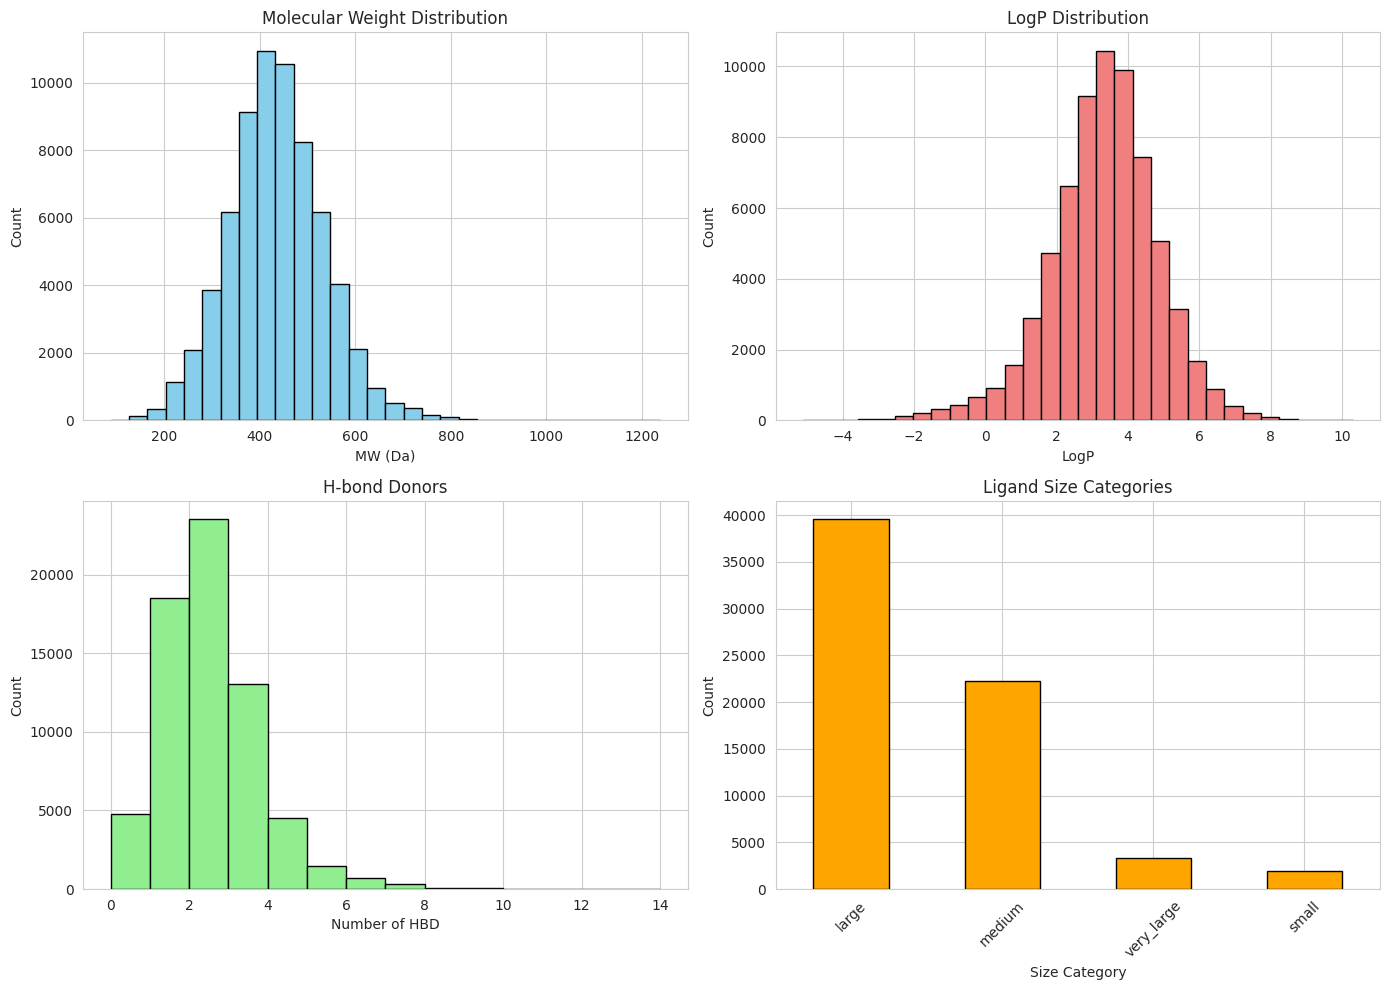

In [106]:
# Visualize ligand properties
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_filtered['mw'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Molecular Weight Distribution')
axes[0, 0].set_xlabel('MW (Da)')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df_filtered['logp'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('LogP Distribution')
axes[0, 1].set_xlabel('LogP')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(df_filtered['hbd'], bins=range(0, 15), color='lightgreen', edgecolor='black')
axes[1, 0].set_title('H-bond Donors')
axes[1, 0].set_xlabel('Number of HBD')
axes[1, 0].set_ylabel('Count')

df_filtered['ligand_size'].value_counts().plot(kind='bar', ax=axes[1, 1], color='orange', edgecolor='black')
axes[1, 1].set_title('Ligand Size Categories')
axes[1, 1].set_xlabel('Size Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Clustering Strategy

In [107]:
# Define cluster keys
cluster_keys = [
    'affinity_tier',
    'protein_family',
    'size_category',
    'ligand_size'
]

# Create composite cluster ID
df_filtered['cluster_id'] = df_filtered[cluster_keys].astype(str).agg('_'.join, axis=1)

n_clusters = df_filtered['cluster_id'].nunique()
print(f"Total clusters: {n_clusters:,}")
print(f"Target samples: {TARGET_SAMPLES}")
print(f"Samples per cluster: {max(1, TARGET_SAMPLES // n_clusters)}")

# Show cluster distribution
cluster_sizes = df_filtered['cluster_id'].value_counts()
print(f"\nCluster size statistics:")
print(f"  Mean: {cluster_sizes.mean():.1f}")
print(f"  Median: {cluster_sizes.median():.0f}")
print(f"  Min: {cluster_sizes.min()}")
print(f"  Max: {cluster_sizes.max()}")

Total clusters: 221
Target samples: 250
Samples per cluster: 1

Cluster size statistics:
  Mean: 303.6
  Median: 48
  Min: 1
  Max: 6314


## 8. Stratified Sampling

In [108]:
print("="*60)
print("STRATIFIED SAMPLING: 250 PROTEINS × (10 TARGETS + 10 OFF-TARGETS)")
print("="*60)

from sklearn.preprocessing import StandardScaler

# Step 1: Sample 250 proteins from valid proteins
n_proteins_to_sample = 250
valid_proteins_list = list(valid_proteins)

if len(valid_proteins_list) > n_proteins_to_sample:
    sampled_proteins = np.random.choice(valid_proteins_list, size=n_proteins_to_sample, replace=False)
    print(f"Sampled {n_proteins_to_sample} proteins from {len(valid_proteins_list)} valid proteins")
else:
    sampled_proteins = valid_proteins_list
    print(f"Using all {len(sampled_proteins)} valid proteins (less than target {n_proteins_to_sample})")

# Step 2: For each sampled protein, take 10 targets + 10 off-targets
final_selection_list = []
n_targets_per_protein = 10
n_offtargets_per_protein = 10

for protein_name in sampled_proteins:
    protein_group = df_filtered[df_filtered['protein'] == protein_name]
    
    # Separate targets and off-targets
    targets = protein_group[protein_group['target_type'] == 'target']
    off_targets = protein_group[protein_group['target_type'] == 'off_target']
    
    # Sample up to 10 of each (or all if fewer than 10)
    if len(targets) > n_targets_per_protein:
        # Prioritize high quality (ipLDDT) and diversity
        targets_sorted = targets.nlargest(20, 'complex_iplddt')  # Top 20 by quality
        targets_selected = targets_sorted.sample(n=min(n_targets_per_protein, len(targets_sorted)), random_state=42)
    else:
        targets_selected = targets
    
    if len(off_targets) > n_offtargets_per_protein:
        off_targets_sorted = off_targets.nlargest(20, 'complex_iplddt')
        off_targets_selected = off_targets_sorted.sample(n=min(n_offtargets_per_protein, len(off_targets_sorted)), random_state=42)
    else:
        off_targets_selected = off_targets
    
    final_selection_list.append(targets_selected)
    final_selection_list.append(off_targets_selected)

# Combine all
final_selection = pd.concat(final_selection_list).drop_duplicates(subset=['entry_id'])

print(f"\n{'='*60}")
print(f"✅ FINAL SELECTION: {len(final_selection):,} samples")
print(f"{'='*60}")

# Statistics
print(f"\nBreakdown:")
print(f"  - Proteins: {final_selection['protein'].nunique()}")
print(f"  - Targets: {(final_selection['target_type'] == 'target').sum()}")
print(f"  - Off-targets: {(final_selection['target_type'] == 'off_target').sum()}")
print(f"  - Mean ipLDDT: {final_selection['complex_iplddt'].mean():.2f}")

# Per-protein balance check
protein_balance = final_selection.groupby('protein')['target_type'].value_counts().unstack(fill_value=0)
print(f"\nPer-protein sampling:")
print(f"  - Average targets per protein: {protein_balance['target'].mean():.1f}")
print(f"  - Average off-targets per protein: {protein_balance['off_target'].mean():.1f}")
print(f"  - Proteins with 10 targets: {(protein_balance['target'] == 10).sum()}")
print(f"  - Proteins with 10 off-targets: {(protein_balance['off_target'] == 10).sum()}")

print(f"\nAffinity tier breakdown:")
for tier in [f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
             f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
             f'weak_binder (>{NON_BINDER_CUTOFF})',
             f'non_binder (≤{NON_BINDER_CUTOFF})']:
    count = (final_selection['affinity_tier'] == tier).sum()
    if count > 0:
        print(f"  {tier}: {count}")

STRATIFIED SAMPLING: 250 PROTEINS × (10 TARGETS + 10 OFF-TARGETS)
Using all 220 valid proteins (less than target 250)

✅ FINAL SELECTION: 4,371 samples

Breakdown:
  - Proteins: 220
  - Targets: 2187
  - Off-targets: 2184
  - Mean ipLDDT: 0.90

Per-protein sampling:
  - Average targets per protein: 9.9
  - Average off-targets per protein: 9.9
  - Proteins with 10 targets: 211
  - Proteins with 10 off-targets: 210

Affinity tier breakdown:
  tight_binder (>=8.5): 587
  moderate_binder (<8.5): 1600
  weak_binder (>4.5): 1801
  non_binder (≤4.5): 383


## 9. Final Selection Analysis

In [109]:
print("Final selection breakdown:")
print(f"\nAffinity tiers:")
print(final_selection['affinity_tier'].value_counts())

print(f"\nProtein families (top 10):")
print(final_selection['protein_family'].value_counts().head(10))

print(f"\nSize categories:")
print(final_selection['size_category'].value_counts())

print(f"\nLigand sizes:")
print(final_selection['ligand_size'].value_counts())

Final selection breakdown:

Affinity tiers:
affinity_tier
weak_binder (>4.5)        1801
moderate_binder (<8.5)    1600
tight_binder (>=8.5)       587
non_binder (≤4.5)          383
Name: count, dtype: int64

Protein families (top 10):
protein_family
enzyme              2588
kinase               992
other                378
phosphatase          275
GPCR                 118
nuclear receptor      20
Name: count, dtype: int64

Size categories:
size_category
large         2029
very_large    1432
medium         810
small          100
Name: count, dtype: int64

Ligand sizes:
ligand_size
medium        2128
large         1685
small          411
very_large     147
Name: count, dtype: int64


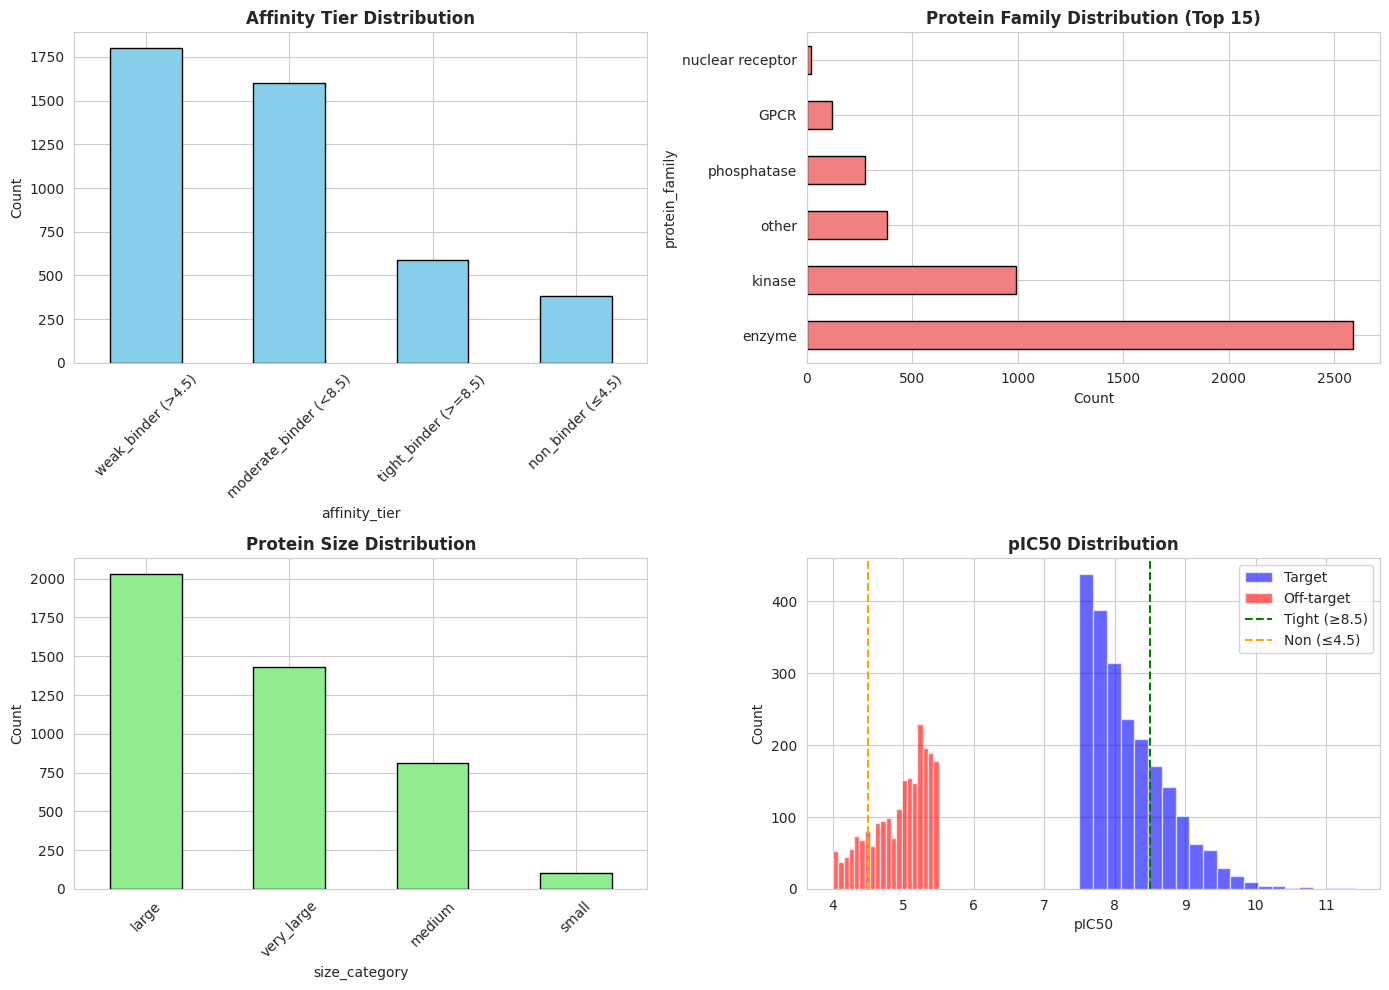

✅ Saved plot to /scratch/yunmin/data/db/graph/sair/clustered/plots/sair_clustering_stage1_distributions.png


In [110]:
# Visualize final selection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Affinity distribution
final_selection['affinity_tier'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Affinity Tier Distribution', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Family distribution (top 15)
final_selection['protein_family'].value_counts().head(15).plot(kind='barh', ax=axes[0, 1], color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Protein Family Distribution (Top 15)', fontweight='bold')
axes[0, 1].set_xlabel('Count')

# Size distribution
final_selection['size_category'].value_counts().plot(kind='bar', ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Protein Size Distribution', fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# pIC50 histogram
axes[1, 1].hist(final_selection[final_selection['target_type'] == 'target']['pIC50'], 
                bins=20, alpha=0.6, label='Target', color='blue')
axes[1, 1].hist(final_selection[final_selection['target_type'] == 'off_target']['pIC50'], 
                bins=20, alpha=0.6, label='Off-target', color='red')
axes[1, 1].axvline(TIGHT_BINDER_CUTOFF, color='green', linestyle='--', label=f'Tight (≥{TIGHT_BINDER_CUTOFF})')
axes[1, 1].axvline(NON_BINDER_CUTOFF, color='orange', linestyle='--', label=f'Non (≤{NON_BINDER_CUTOFF})')
axes[1, 1].set_title('pIC50 Distribution', fontweight='bold')
axes[1, 1].set_xlabel('pIC50')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'plots' / 'sair_clustering_stage1_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved plot to {OUT_DIR / 'plots' / 'sair_clustering_stage1_distributions.png'}")

GENERATING BEFORE/AFTER t-SNE COMPARISON
Running t-SNE on filtered dataset (before sampling)...
  Sampling 5000 points from 67102 for visualization...
Locating final selection in t-SNE space...
  Found 323 / 4371 samples in visualization


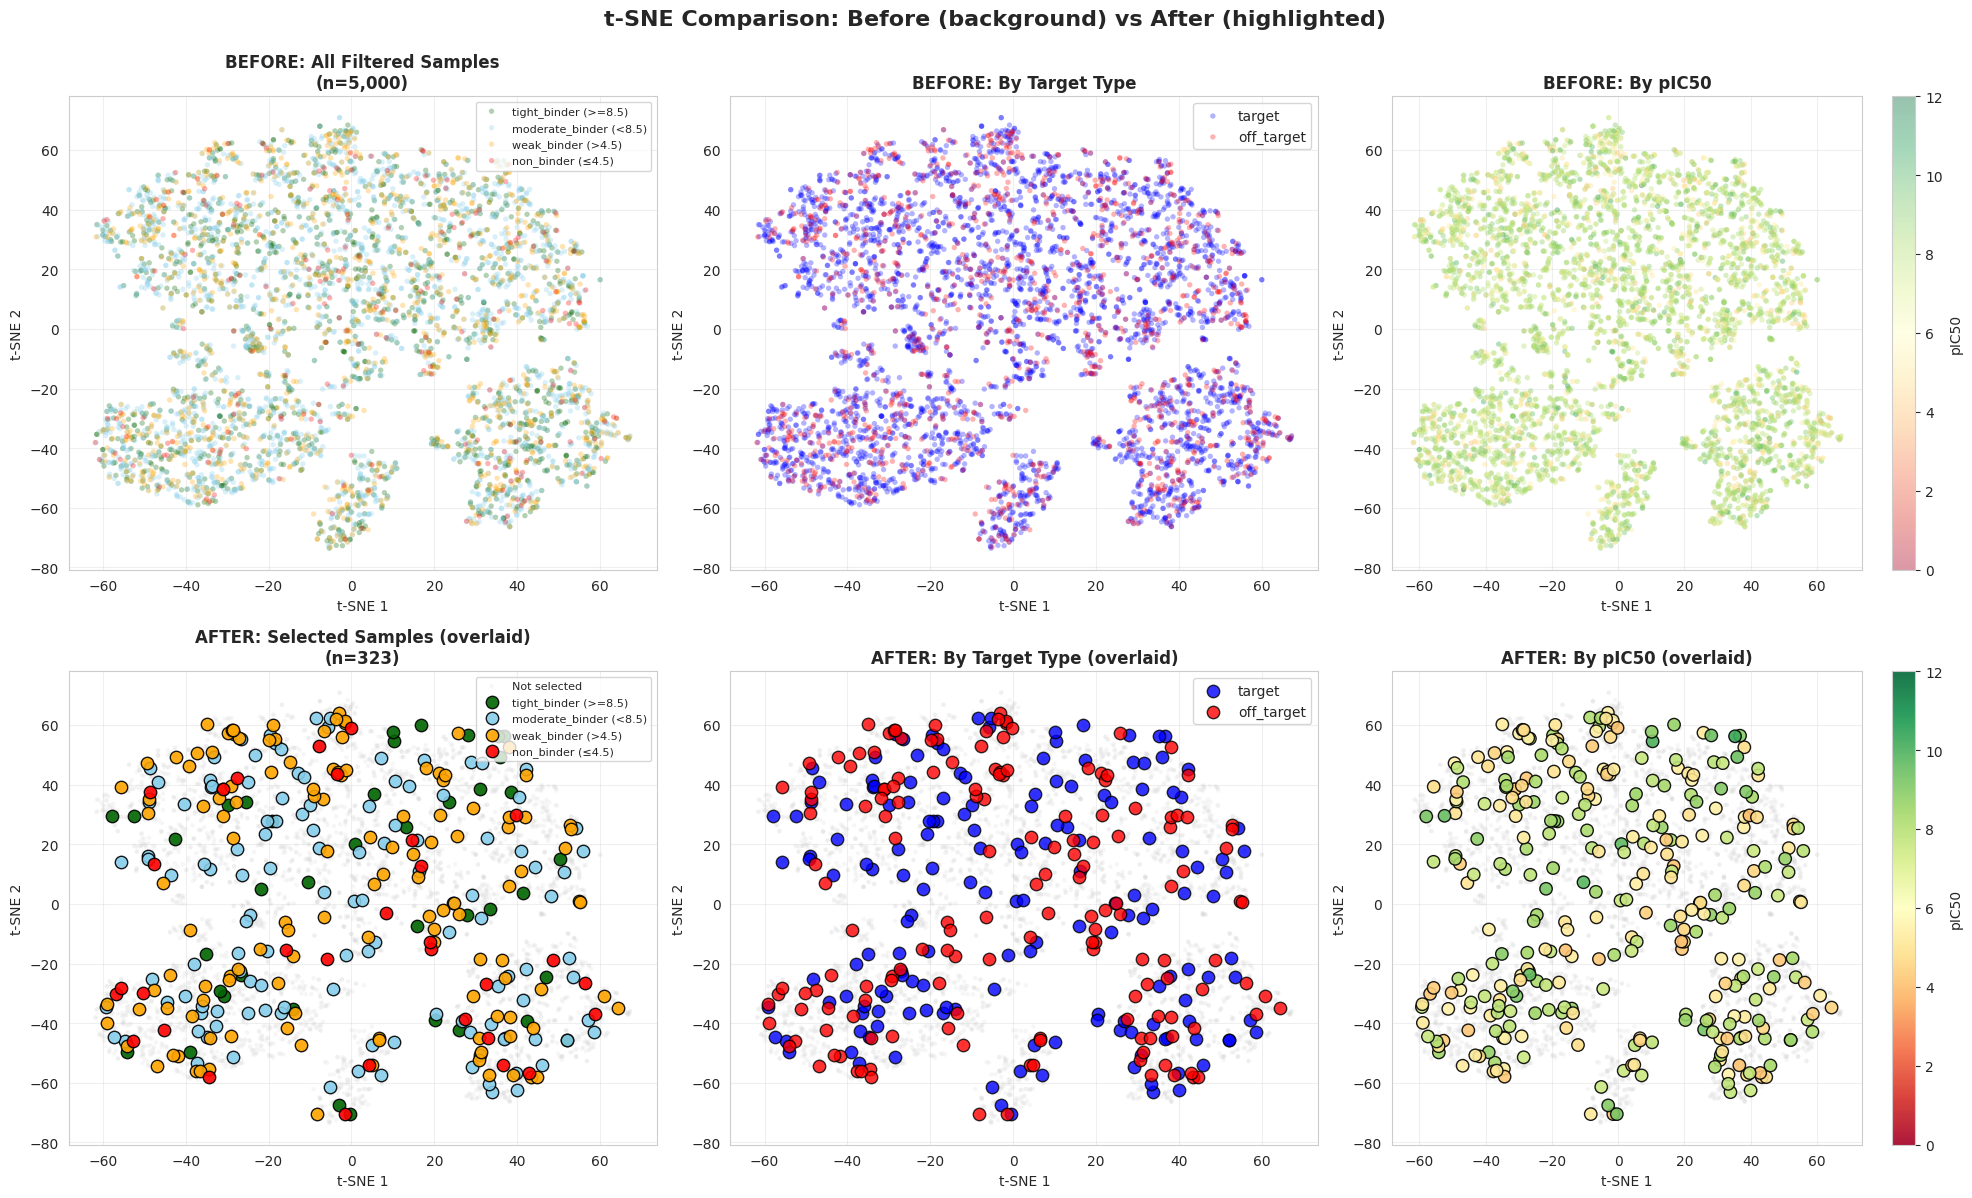

✅ Saved before/after t-SNE plot to /scratch/yunmin/data/db/graph/sair/clustered/sair_clustering_tsne_before_after.png

SAMPLING IMPACT ANALYSIS

Dataset size:
  Before: 67,102 samples
  After:  4,371 samples
  Reduction: 93.5%

Affinity tier balance:
  Tier                                     Before     After      Change
  ----------------------------------------------------------------------
  moderate_binder (<8.5)                     46.5%      36.6%    -9.9%
  tight_binder (>=8.5)                       27.1%      13.4%    -13.7%
  weak_binder (>4.5)                         22.0%      41.2%    +19.2%
  non_binder (≤4.5)                           4.3%       8.8%    +4.4%

Target/Off-target balance:
  Targets:     Before 73.6% → After 50.0%
  Off-targets: Before 26.4% → After 50.0%


In [111]:
### Before/After t-SNE Comparison
print("="*60)
print("GENERATING BEFORE/AFTER t-SNE COMPARISON")
print("="*60)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Prepare features for the FILTERED dataset (before sampling)
print("Running t-SNE on filtered dataset (before sampling)...")
tsne_features_before = df_filtered[['mw', 'logp', 'hbd', 'hba', 'rotatable_bonds', 
                                     'aromatic_rings', 'heavy_atoms', 'pIC50', 
                                     'sequence_length', 'complex_iplddt']].copy()
tsne_features_before = tsne_features_before.fillna(tsne_features_before.median())

# Standardize
scaler = StandardScaler()
tsne_features_before_scaled = scaler.fit_transform(tsne_features_before)

# Run t-SNE (sample if too large)
if len(df_filtered) > 5000:
    print(f"  Sampling {5000} points from {len(df_filtered)} for visualization...")
    sample_idx = df_filtered.sample(n=5000, random_state=42).index
    df_before_viz = df_filtered.loc[sample_idx]
    tsne_before_scaled = tsne_features_before_scaled[df_filtered.index.isin(sample_idx)]
else:
    df_before_viz = df_filtered
    tsne_before_scaled = tsne_features_before_scaled

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_before_viz)-1))
tsne_coords_before = tsne.fit_transform(tsne_before_scaled)

# Find AFTER samples in the BEFORE coordinates
print("Locating final selection in t-SNE space...")
after_indices_in_before = df_before_viz.index.isin(final_selection.index)
tsne_coords_after_overlay = tsne_coords_before[after_indices_in_before]
final_selection_overlay = df_before_viz[after_indices_in_before]

print(f"  Found {len(final_selection_overlay)} / {len(final_selection)} samples in visualization")

# Create comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('t-SNE Comparison: Before (background) vs After (highlighted)', 
             fontsize=16, fontweight='bold', y=0.995)

# Column 1: By Affinity Tier
# Top: All samples (background)
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = df_before_viz['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[0, 0].scatter(tsne_coords_before[mask, 0], tsne_coords_before[mask, 1], 
                          c=color, label=tier, alpha=0.3, s=15, edgecolors='none')
axes[0, 0].set_title(f'BEFORE: All Filtered Samples\n(n={len(df_before_viz):,})', 
                     fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].grid(True, alpha=0.3)

# Bottom: Selected samples OVERLAID on same coordinates
axes[1, 0].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                   c='lightgray', alpha=0.2, s=10, edgecolors='none', label='Not selected')
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = final_selection_overlay['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[1, 0].scatter(tsne_coords_after_overlay[mask, 0], tsne_coords_after_overlay[mask, 1], 
                          c=color, label=tier, alpha=0.9, s=80, edgecolors='black', linewidth=1)
axes[1, 0].set_title(f'AFTER: Selected Samples (overlaid)\n(n={len(final_selection_overlay):,})', 
                     fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
axes[1, 0].legend(fontsize=8, loc='best')
axes[1, 0].grid(True, alpha=0.3)

# Column 2: By Target Type
# Top: All samples
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = df_before_viz['target_type'] == ttype
    axes[0, 1].scatter(tsne_coords_before[mask, 0], tsne_coords_before[mask, 1], 
                      c=color, label=ttype, alpha=0.3, s=15, edgecolors='none')
axes[0, 1].set_title(f'BEFORE: By Target Type', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bottom: Selected samples overlaid
axes[1, 1].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                   c='lightgray', alpha=0.2, s=10, edgecolors='none')
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = final_selection_overlay['target_type'] == ttype
    axes[1, 1].scatter(tsne_coords_after_overlay[mask, 0], tsne_coords_after_overlay[mask, 1], 
                      c=color, label=ttype, alpha=0.8, s=80, edgecolors='black', linewidth=1)
axes[1, 1].set_title(f'AFTER: By Target Type (overlaid)', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('t-SNE 1')
axes[1, 1].set_ylabel('t-SNE 2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Column 3: By pIC50
# Top: All samples
scatter_before = axes[0, 2].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                                    c=df_before_viz['pIC50'], cmap='RdYlGn', 
                                    alpha=0.4, s=15, edgecolors='none', vmin=0, vmax=12)
axes[0, 2].set_title(f'BEFORE: By pIC50', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('t-SNE 1')
axes[0, 2].set_ylabel('t-SNE 2')
axes[0, 2].grid(True, alpha=0.3)
plt.colorbar(scatter_before, ax=axes[0, 2], label='pIC50')

# Bottom: Selected samples overlaid
axes[1, 2].scatter(tsne_coords_before[:, 0], tsne_coords_before[:, 1], 
                   c='lightgray', alpha=0.2, s=10, edgecolors='none')
scatter_after = axes[1, 2].scatter(tsne_coords_after_overlay[:, 0], tsne_coords_after_overlay[:, 1], 
                                   c=final_selection_overlay['pIC50'], cmap='RdYlGn', 
                                   alpha=0.9, s=80, edgecolors='black', linewidth=1, vmin=0, vmax=12)
axes[1, 2].set_title(f'AFTER: By pIC50 (overlaid)', fontweight='bold', fontsize=12)
axes[1, 2].set_xlabel('t-SNE 1')
axes[1, 2].set_ylabel('t-SNE 2')
axes[1, 2].grid(True, alpha=0.3)
plt.colorbar(scatter_after, ax=axes[1, 2], label='pIC50')

plt.tight_layout()
plt.savefig(OUT_DIR / 'sair_clustering_tsne_before_after.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved before/after t-SNE plot to {OUT_DIR / 'sair_clustering_tsne_before_after.png'}")

# Print comparison statistics
print(f"\n{'='*60}")
print("SAMPLING IMPACT ANALYSIS")
print(f"{'='*60}")
print(f"\nDataset size:")
print(f"  Before: {len(df_filtered):,} samples")
print(f"  After:  {len(final_selection):,} samples")
print(f"  Reduction: {(1 - len(final_selection)/len(df_filtered))*100:.1f}%")

print(f"\nAffinity tier balance:")
before_affinity = df_filtered['affinity_tier'].value_counts(normalize=True) * 100
after_affinity = final_selection['affinity_tier'].value_counts(normalize=True) * 100
print(f"  {'Tier':<40} {'Before':<10} {'After':<10} {'Change'}")
print(f"  {'-'*70}")
for tier in before_affinity.index:
    before_pct = before_affinity.get(tier, 0)
    after_pct = after_affinity.get(tier, 0)
    change = after_pct - before_pct
    print(f"  {tier:<40} {before_pct:>6.1f}%    {after_pct:>6.1f}%    {change:+.1f}%")

print(f"\nTarget/Off-target balance:")
before_target = (df_filtered['target_type'] == 'target').sum() / len(df_filtered) * 100
after_target = (final_selection['target_type'] == 'target').sum() / len(final_selection) * 100
print(f"  Targets:     Before {before_target:.1f}% → After {after_target:.1f}%")
print(f"  Off-targets: Before {100-before_target:.1f}% → After {100-after_target:.1f}%")

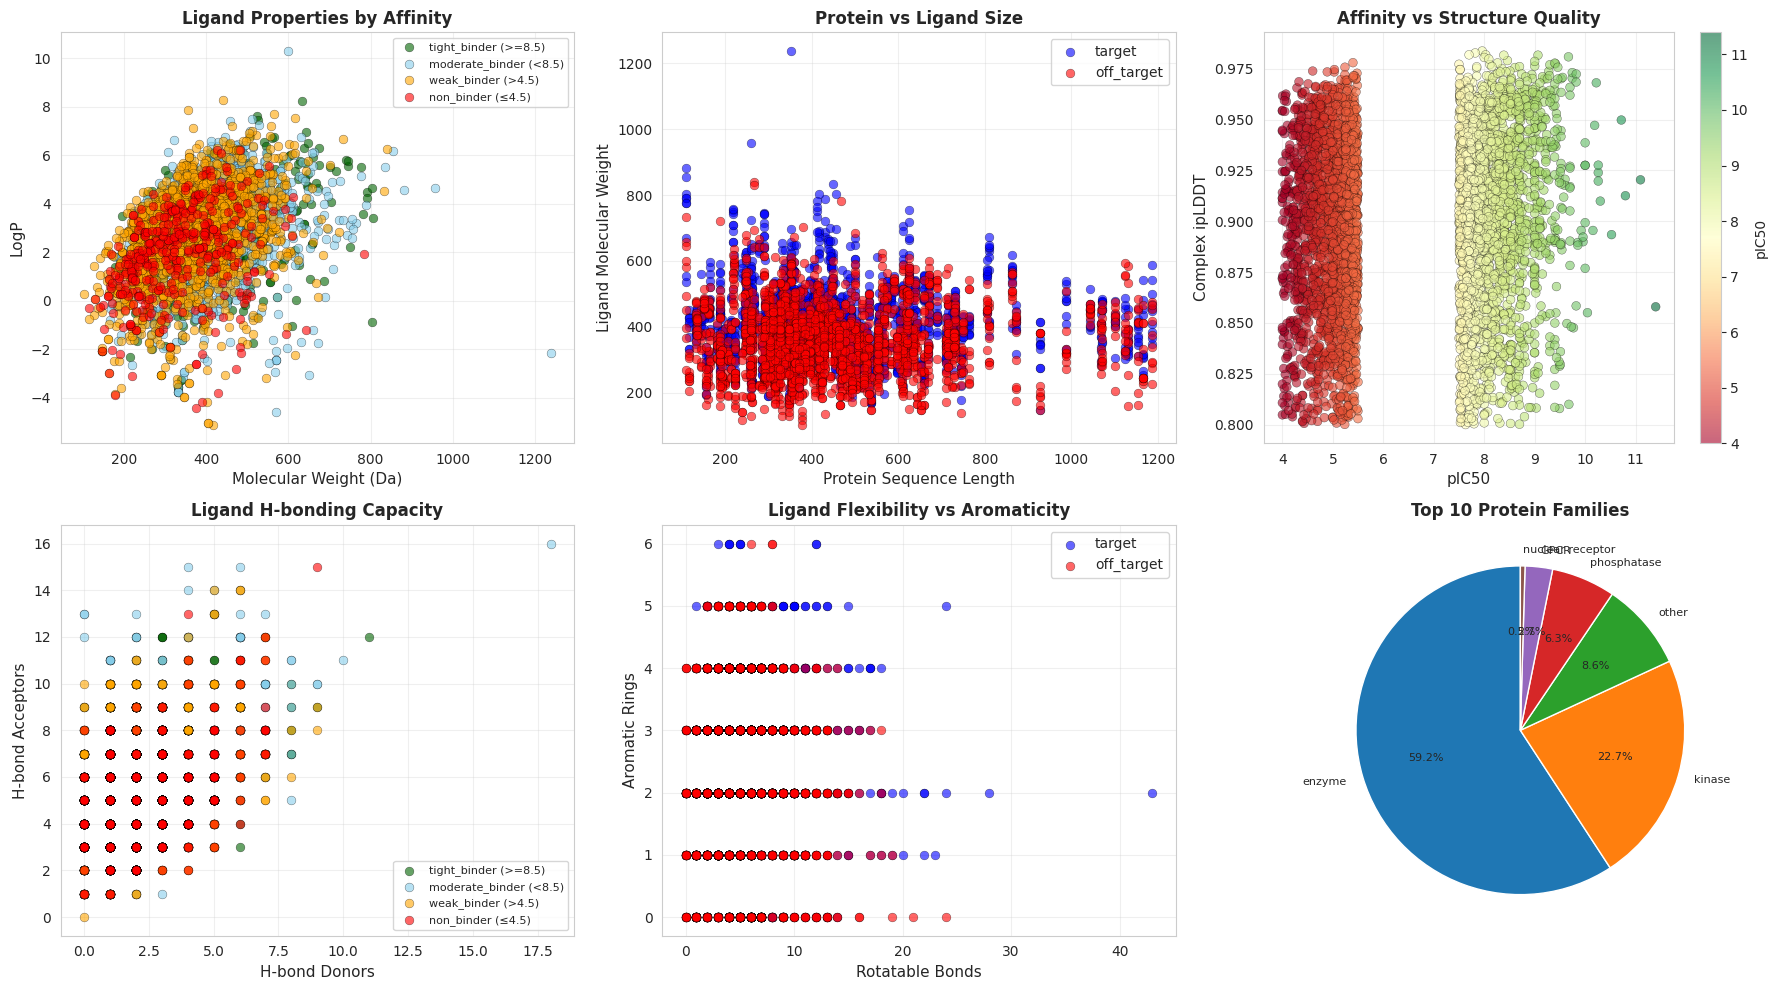

✅ Saved scatter analysis to /scratch/yunmin/data/db/graph/sair/clustered/plots/sair_clustering_scatter_analysis.png


In [112]:
### Multi-dimensional Scatter Plots

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Molecular Weight vs LogP (colored by affinity)
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = final_selection['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[0, 0].scatter(final_selection[mask]['mw'], final_selection[mask]['logp'], 
                          c=color, label=tier, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[0, 0].set_xlabel('Molecular Weight (Da)', fontsize=11)
axes[0, 0].set_ylabel('LogP', fontsize=11)
axes[0, 0].set_title('Ligand Properties by Affinity', fontweight='bold')
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].grid(True, alpha=0.3)

# 2. Protein Size vs Ligand Size (colored by target type)
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = final_selection['target_type'] == ttype
    axes[0, 1].scatter(final_selection[mask]['sequence_length'], final_selection[mask]['mw'], 
                      c=color, label=ttype, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[0, 1].set_xlabel('Protein Sequence Length', fontsize=11)
axes[0, 1].set_ylabel('Ligand Molecular Weight', fontsize=11)
axes[0, 1].set_title('Protein vs Ligand Size', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. pIC50 vs Complex Quality
scatter = axes[0, 2].scatter(final_selection['pIC50'], final_selection['complex_iplddt'], 
                            c=final_selection['pIC50'], cmap='RdYlGn', 
                            alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[0, 2].set_xlabel('pIC50', fontsize=11)
axes[0, 2].set_ylabel('Complex ipLDDT', fontsize=11)
axes[0, 2].set_title('Affinity vs Structure Quality', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 2], label='pIC50')

# 4. HBD vs HBA (colored by affinity)
for tier, color in zip([f'tight_binder (>={TIGHT_BINDER_CUTOFF})', 
                        f'moderate_binder (<{TIGHT_BINDER_CUTOFF})',
                        f'weak_binder (>{NON_BINDER_CUTOFF})',
                        f'non_binder (≤{NON_BINDER_CUTOFF})'],
                       ['darkgreen', 'skyblue', 'orange', 'red']):
    mask = final_selection['affinity_tier'] == tier
    if mask.sum() > 0:
        axes[1, 0].scatter(final_selection[mask]['hbd'], final_selection[mask]['hba'], 
                          c=color, label=tier, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[1, 0].set_xlabel('H-bond Donors', fontsize=11)
axes[1, 0].set_ylabel('H-bond Acceptors', fontsize=11)
axes[1, 0].set_title('Ligand H-bonding Capacity', fontweight='bold')
axes[1, 0].legend(fontsize=8, loc='best')
axes[1, 0].grid(True, alpha=0.3)

# 5. Rotatable Bonds vs Aromatic Rings
for ttype, color in zip(['target', 'off_target'], ['blue', 'red']):
    mask = final_selection['target_type'] == ttype
    axes[1, 1].scatter(final_selection[mask]['rotatable_bonds'], final_selection[mask]['aromatic_rings'], 
                      c=color, label=ttype, alpha=0.6, s=40, edgecolors='black', linewidth=0.3)
axes[1, 1].set_xlabel('Rotatable Bonds', fontsize=11)
axes[1, 1].set_ylabel('Aromatic Rings', fontsize=11)
axes[1, 1].set_title('Ligand Flexibility vs Aromaticity', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Protein Family Distribution (pie chart)
family_counts = final_selection['protein_family'].value_counts().head(10)
axes[1, 2].pie(family_counts.values, labels=family_counts.index, autopct='%1.1f%%', 
               startangle=90, textprops={'fontsize': 8})
axes[1, 2].set_title('Top 10 Protein Families', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'sair_clustering_scatter_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved scatter analysis to {OUT_DIR / 'plots' / 'sair_clustering_scatter_analysis.png'}")

## 10. Diversity Analysis

In [113]:
def shannon_entropy(counts):
    """Calculate Shannon entropy for diversity."""
    total = counts.sum()
    probs = counts / total
    return -np.sum(probs * np.log2(probs + 1e-10))

family_entropy = shannon_entropy(final_selection['protein_family'].value_counts())
size_entropy = shannon_entropy(final_selection['size_category'].value_counts())
affinity_entropy = shannon_entropy(final_selection['affinity_tier'].value_counts())

print("Diversity scores (higher = more diverse):")
print(f"  - Family diversity: {family_entropy:.2f}")
print(f"  - Size diversity: {size_entropy:.2f}")
print(f"  - Affinity diversity: {affinity_entropy:.2f}")

Diversity scores (higher = more diverse):
  - Family diversity: 1.67
  - Size diversity: 1.62
  - Affinity diversity: 1.75


## 11. Save Outputs

In [114]:
# Save clustered dataset
output_path = OUT_DIR / "sair_clustered_stage1.csv"
final_selection.to_csv(output_path, index=False)
print(f"✅ Saved clustered dataset: {output_path}")

# Save metadata
metadata = {
    "pipeline": "SAIR Fast Clustering (Stage 1)",
    "timestamp": datetime.now().isoformat(),
    "input": {
        "file": INPUT_CSV,
        "initial_rows": initial_rows,
        "initial_proteins": int(df['protein'].nunique())
    },
    "filtering": {
        "min_targets_per_protein": MIN_TARGETS_PER_PROTEIN,
        "min_offtargets_per_protein": MIN_OFFTARGETS_PER_PROTEIN,
        "proteins_after_filter": len(valid_proteins),
        "rows_after_filter": len(df_filtered)
    },
    "clustering_criteria": {
        "tight_binder_cutoff": TIGHT_BINDER_CUTOFF,
        "non_binder_cutoff": NON_BINDER_CUTOFF,
        "cluster_keys": cluster_keys,
        "total_clusters": int(n_clusters)
    },
    "sampling_strategy": {
        "method": "balanced_per_protein",
        "max_samples_per_protein": 3,  # Adjust based on your actual value
        "target_total_samples": TARGET_SAMPLES,
        "proteins_sampled": len(proteins_sampled) if 'proteins_sampled' in locals() else int(final_selection['protein'].nunique())
    },
    "output": {
        "total_selected": len(final_selection),
        "targets_selected": int((final_selection['target_type'] == 'target').sum()),
        "offtargets_selected": int((final_selection['target_type'] == 'off_target').sum()),
        "unique_proteins": int(final_selection['protein'].nunique()),
        "affinity_distribution": {k: int(v) for k, v in final_selection['affinity_tier'].value_counts().to_dict().items()},
        "family_distribution": {k: int(v) for k, v in final_selection['protein_family'].value_counts().head(20).to_dict().items()},
        "size_distribution": {k: int(v) for k, v in final_selection['size_category'].value_counts().to_dict().items()},
        "diversity_scores": {
            "family": float(family_entropy),
            "size": float(size_entropy),
            "affinity": float(affinity_entropy)
        }
    }
}

metadata_path = OUT_DIR / "sair_clustering_stage1_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Saved metadata: {metadata_path}")

print("\n" + "="*60)
print("STAGE 1 COMPLETE")
print("="*60)
print(f"Next: Run Stage 2 validation on {output_path}")

✅ Saved clustered dataset: /scratch/yunmin/data/db/graph/sair/clustered/sair_clustered_stage1.csv
✅ Saved metadata: /scratch/yunmin/data/db/graph/sair/clustered/sair_clustering_stage1_metadata.json

STAGE 1 COMPLETE
Next: Run Stage 2 validation on /scratch/yunmin/data/db/graph/sair/clustered/sair_clustered_stage1.csv
